In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Product Demand & Inventory Analytics

## 1. Introduction

## 2. Data Loading

## 3. Data Cleaning
- Missing values
- Demand conversion
- Date conversion

## 4. Exploratory Data Analysis
- Warehouse analysis
- Category analysis
- Product analysis
- Monthly/yearly trends
- Category growth


In [2]:
df = pd.read_csv("/kaggle/input/datasets/felixzhao/productdemandforecasting/Historical Product Demand.csv")

df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1048575
Columns: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [4]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(122423)

In [6]:
df.describe(include='all')

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


In [7]:
df['Order_Demand'].astype(str).str.strip().head(20)

0        100
1        500
2        500
3        500
4        500
5        500
6        500
7        500
8        500
9        500
10       500
11       500
12       500
13       500
14       500
15       500
16     50000
17    100000
18     50000
19     50000
Name: Order_Demand, dtype: object

In [8]:
demand_numeric = pd.to_numeric(
    df['Order_Demand'].astype(str).str.strip().str.replace(',', '', regex=False),
    errors='coerce'
)

df.loc[demand_numeric.isna(), 'Order_Demand'].value_counts().head(20)

Order_Demand
(100)     1199
(200)      902
(1000)     591
(1)        542
(300)      494
(500)      438
(400)      373
(2)        367
(50)       295
(10)       259
(2000)     238
(600)      194
(4)        177
(5)        164
(3)        154
(20)       141
(25)       133
(700)      132
(6)        106
(1500)     102
Name: count, dtype: int64

In [9]:
print("Non-numeric values:", demand_numeric.isna().sum())

Non-numeric values: 10469


In [10]:
df['Order_Demand'] = (
    df['Order_Demand']
    .astype(str)
    .str.strip()
    .str.replace(',', '', regex=False)
    .str.replace(r'^\((.*)\)$', r'-\1', regex=True)
)

df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')

df['Order_Demand'].describe()

count    1.048575e+06
mean     4.867427e+03
std      2.893346e+04
min     -9.990000e+05
25%      1.800000e+01
50%      3.000000e+02
75%      2.000000e+03
max      4.000000e+06
Name: Order_Demand, dtype: float64

In [11]:
print("Missing demand:", df['Order_Demand'].isna().sum())
print("Negative demand:", (df['Order_Demand'] < 0).sum())

Missing demand: 0
Negative demand: 10469


In [12]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Missing dates:", df['Date'].isna().sum())
print("Earliest date:", df['Date'].min())
print("Latest date:", df['Date'].max())

Missing dates: 11239
Earliest date: 2011-01-08 00:00:00
Latest date: 2017-01-09 00:00:00


In [13]:
df['Date'].isna().sum()

np.int64(11239)

In [14]:
df_clean = df.dropna(subset=['Date']).copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 1048575
Cleaned rows: 1037336
Rows removed: 11239


In [15]:
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

df_clean.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0965,Whse_A,Category_006,2011-01-08,2
1,Product_1724,Whse_A,Category_003,2011-05-31,108
2,Product_1521,Whse_S,Category_019,2011-06-24,85000
3,Product_1521,Whse_S,Category_019,2011-06-24,7000
4,Product_1507,Whse_C,Category_019,2011-09-02,1250


In [16]:
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.month_name()
df_clean['Month_Year'] = df_clean['Date'].dt.to_period('M').astype(str)

df_clean.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,Month_Name,Month_Year
0,Product_0965,Whse_A,Category_006,2011-01-08,2,2011,1,January,2011-01
1,Product_1724,Whse_A,Category_003,2011-05-31,108,2011,5,May,2011-05
2,Product_1521,Whse_S,Category_019,2011-06-24,85000,2011,6,June,2011-06
3,Product_1521,Whse_S,Category_019,2011-06-24,7000,2011,6,June,2011-06
4,Product_1507,Whse_C,Category_019,2011-09-02,1250,2011,9,September,2011-09


In [17]:
df_clean[['Date', 'Year', 'Month', 'Month_Name', 'Month_Year']].head(10)

,Date,Year,Month,Month_Name,Month_Year
0,2011-01-08,2011,1,January,2011-01
1,2011-05-31,2011,5,May,2011-05
2,2011-06-24,2011,6,June,2011-06
3,2011-06-24,2011,6,June,2011-06
4,2011-09-02,2011,9,September,2011-09
5,2011-09-27,2011,9,September,2011-09
6,2011-09-27,2011,9,September,2011-09
7,2011-09-30,2011,9,September,2011-09
8,2011-10-20,2011,10,October,2011-10
9,2011-10-20,2011,10,October,2011-10


In [18]:
print("Total Demand:", df_clean['Order_Demand'].sum())
print("Average Demand:", df_clean['Order_Demand'].mean())
print("Median Demand:", df_clean['Order_Demand'].median())
print("Number of Products:", df_clean['Product_Code'].nunique())
print("Number of Warehouses:", df_clean['Warehouse'].nunique())
print("Number of Categories:", df_clean['Product_Category'].nunique())

Total Demand: 5103852231
Average Demand: 4920.153384245798
Median Demand: 300.0
Number of Products: 2160
Number of Warehouses: 4
Number of Categories: 33


In [19]:
df_clean['Warehouse'].value_counts()

Warehouse
Whse_J    764447
Whse_A    142335
Whse_S     88200
Whse_C     42354
Name: count, dtype: int64

In [20]:
warehouse_demand = (
    df_clean.groupby('Warehouse')['Order_Demand']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
)

warehouse_demand

,sum,mean,count
Warehouse,,,
Whse_J,3344521718,4375.086459,764447
Whse_S,1034227618,11725.936712,88200
Whse_C,581845212,13737.668508,42354
Whse_A,143257683,1006.482474,142335


In [21]:
warehouse_demand['demand_share_%'] = (
    warehouse_demand['sum'] / df_clean['Order_Demand'].sum() * 100
).round(2)

warehouse_demand

,sum,mean,count,demand_share_%
Warehouse,,,,
Whse_J,3344521718,4375.086459,764447,65.53
Whse_S,1034227618,11725.936712,88200,20.26
Whse_C,581845212,13737.668508,42354,11.40
Whse_A,143257683,1006.482474,142335,2.81


In [22]:
category_demand = (
    df_clean.groupby('Product_Category')['Order_Demand']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
)

category_demand.head(10)

,sum,mean,count
Product_Category,,,
Category_019,4219806665,8973.233585,470266
Category_006,401649668,11297.526665,35552
Category_005,198361890,1951.862104,101627
Category_007,127725843,1550.033288,82402
Category_028,47276346,1524.453308,31012
Category_033,42370000,22915.089237,1849
Category_030,39781355,3060.810572,12997
Category_032,4445960,478.265921,9296
Category_021,4349008,83.621904,52008


In [23]:
category_demand['demand_share_%'] = (
    category_demand['sum'] / df_clean['Order_Demand'].sum() * 100
).round(2)

category_demand.head(10)

,sum,mean,count,demand_share_%
Product_Category,,,,
Category_019,4219806665,8973.233585,470266,82.68
Category_006,401649668,11297.526665,35552,7.87
Category_005,198361890,1951.862104,101627,3.89
Category_007,127725843,1550.033288,82402,2.50
Category_028,47276346,1524.453308,31012,0.93
Category_033,42370000,22915.089237,1849,0.83
Category_030,39781355,3060.810572,12997,0.78
Category_032,4445960,478.265921,9296,0.09
Category_021,4349008,83.621904,52008,0.09


In [24]:
product_demand = (
    df_clean.groupby('Product_Code')['Order_Demand']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
)

product_demand.head(10)

,sum,mean,count
Product_Code,,,
Product_1359,470710000,27793.457723,16936
Product_1248,288927000,45514.650284,6348
Product_0083,210427000,105901.862104,1987
Product_1341,169777000,63658.417698,2667
Product_1295,121992000,11535.886525,10575
Product_1241,115385000,21071.037253,5476
Product_1245,102937000,180591.228070,570
Product_1286,101331800,11400.967597,8888
Product_1432,97005000,32335.000000,3000


In [25]:
product_demand['demand_share_%'] = (
    product_demand['sum'] / df_clean['Order_Demand'].sum() * 100
).round(2)

product_demand.head(10)

,sum,mean,count,demand_share_%
Product_Code,,,,
Product_1359,470710000,27793.457723,16936,9.22
Product_1248,288927000,45514.650284,6348,5.66
Product_0083,210427000,105901.862104,1987,4.12
Product_1341,169777000,63658.417698,2667,3.33
Product_1295,121992000,11535.886525,10575,2.39
Product_1241,115385000,21071.037253,5476,2.26
Product_1245,102937000,180591.228070,570,2.02
Product_1286,101331800,11400.967597,8888,1.99
Product_1432,97005000,32335.000000,3000,1.90


In [26]:
monthly_demand = (
    df_clean.groupby('Month_Year')['Order_Demand']
    .agg(['sum', 'count'])
    .reset_index()
)

monthly_demand.head(10)

,Month_Year,sum,count
0,2011-01,2,1
1,2011-05,108,1
2,2011-06,92000,2
3,2011-09,6728,4
4,2011-10,-1,3
5,2011-11,85202,31
6,2011-12,7325947,598
7,2012-01,74098835,15614
8,2012-02,86471824,18123
9,2012-03,85524550,18604


In [27]:
monthly_demand['Month_Year'] = pd.to_datetime(monthly_demand['Month_Year'])

monthly_demand = monthly_demand.sort_values('Month_Year')

monthly_demand.head()

,Month_Year,sum,count
0,2011-01-01,2,1
1,2011-05-01,108,1
2,2011-06-01,92000,2
3,2011-09-01,6728,4
4,2011-10-01,-1,3


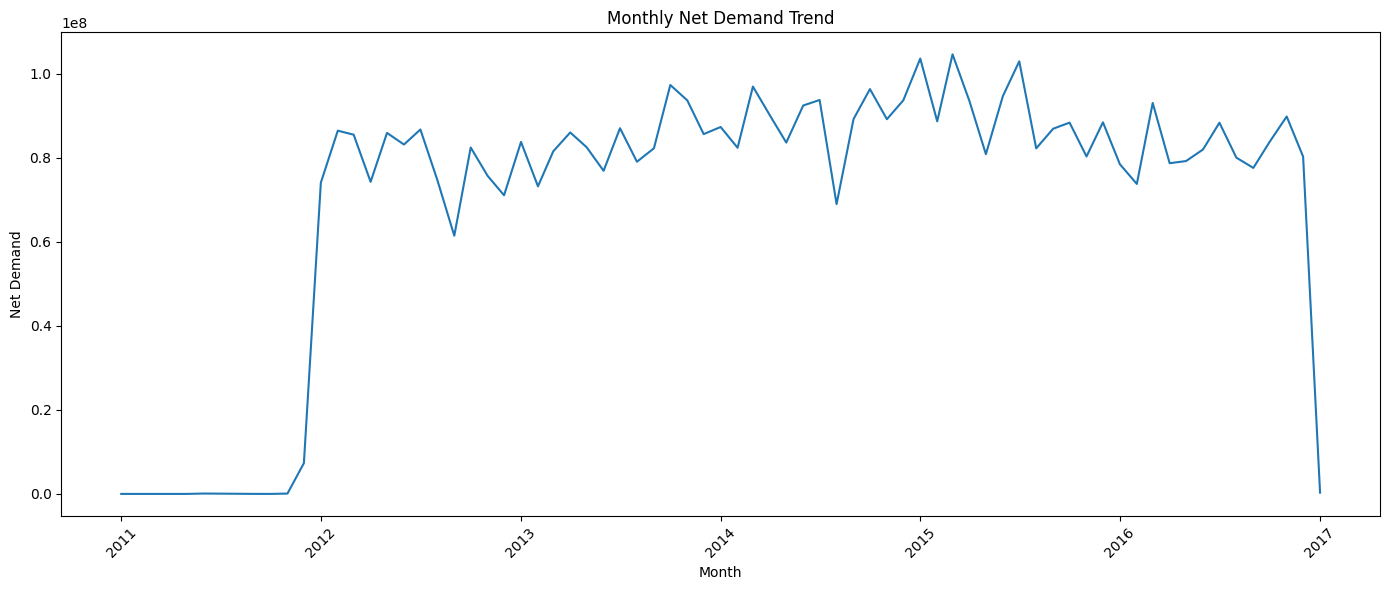

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand['Month_Year'],
    monthly_demand['sum']
)

plt.title('Monthly Net Demand Trend')
plt.xlabel('Month')
plt.ylabel('Net Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
yearly_demand = (
    df_clean.groupby('Year')['Order_Demand']
    .agg(['sum', 'mean', 'count'])
    .reset_index()
)

yearly_demand

,Year,sum,mean,count
0,2011,7509986,11734.353125,640
1,2012,941742907,4624.661316,203635
2,2013,1009218798,4623.124344,218298
3,2014,1064272479,4917.988942,216404
4,2015,1095444965,5224.838978,209661
5,2016,985368129,5223.399131,188645
6,2017,294967,5565.415094,53


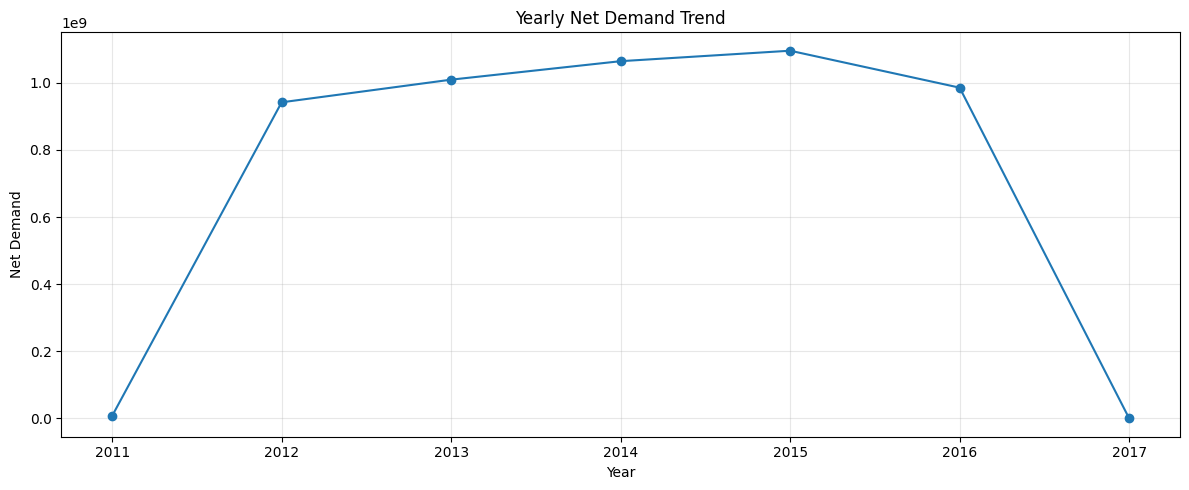

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    yearly_demand['Year'],
    yearly_demand['sum'],
    marker='o'
)

plt.title('Yearly Net Demand Trend')
plt.xlabel('Year')
plt.ylabel('Net Demand')
plt.xticks(yearly_demand['Year'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
monthly_pattern = (
    df_clean.groupby('Month_Name')['Order_Demand']
    .agg(['sum', 'mean', 'count'])
)

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_pattern = monthly_pattern.reindex(month_order)

monthly_pattern

,sum,mean,count
Month_Name,,,
January,427666701,5147.711227,83079
February,404597396,4613.320061,87702
March,461797574,5006.261372,92244
April,422710848,4962.676372,85178
May,412237335,5058.188873,81499
June,429345815,4996.634527,85927
July,458951249,5092.894148,90116
August,385119643,4813.213390,80013
September,397548827,4646.161713,85565


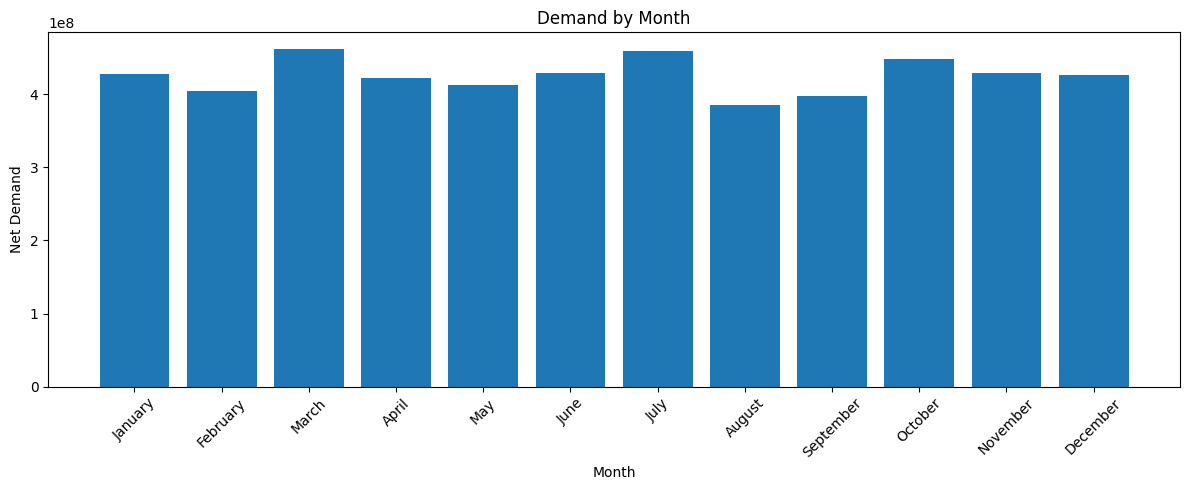

In [32]:
plt.figure(figsize=(12, 5))

plt.bar(
    monthly_pattern.index,
    monthly_pattern['sum']
)

plt.title('Demand by Month')
plt.xlabel('Month')
plt.ylabel('Net Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
category_warehouse = (
    df_clean.groupby(['Product_Category', 'Warehouse'])['Order_Demand']
    .sum()
    .reset_index()
)

category_warehouse.sort_values(
    'Order_Demand',
    ascending=False
).head(15)

,Product_Category,Warehouse,Order_Demand
57,Category_019,Whse_J,2724773093
58,Category_019,Whse_S,871596358
56,Category_019,Whse_C,519591473
15,Category_006,Whse_J,317097080
11,Category_005,Whse_J,128067040
19,Category_007,Whse_J,111457008
55,Category_019,Whse_A,103845741
12,Category_005,Whse_S,56990850
93,Category_033,Whse_J,42370000
16,Category_006,Whse_S,40510693


In [34]:
category_warehouse_pivot = category_warehouse.pivot(
    index='Product_Category',
    columns='Warehouse',
    values='Order_Demand'
).fillna(0)

category_warehouse_pivot.head(10)

Warehouse,Whse_A,Whse_C,Whse_J,Whse_S
Product_Category,,,,
Category_001,1739.0,59946.0,1594238.0,72476.0
Category_002,0.0,0.0,0.0,620.0
Category_003,130743.0,0.0,39225.0,218476.0
Category_004,0.0,0.0,0.0,97508.0
Category_005,1098700.0,12205300.0,128067040.0,56990850.0
Category_006,11358395.0,32683500.0,317097080.0,40510693.0
Category_007,2727768.0,7101252.0,111457008.0,6439815.0
Category_008,1899.0,317.0,15306.0,0.0
Category_009,810647.0,251031.0,442715.0,2104600.0


In [35]:
product_demand = (
    df_clean.groupby('Product_Code')['Order_Demand']
    .agg(['sum', 'mean', 'count'])
    .sort_values('sum', ascending=False)
)

product_demand.head(15)

,sum,mean,count
Product_Code,,,
Product_1359,470710000,27793.457723,16936
Product_1248,288927000,45514.650284,6348
Product_0083,210427000,105901.862104,1987
Product_1341,169777000,63658.417698,2667
Product_1295,121992000,11535.886525,10575
Product_1241,115385000,21071.037253,5476
Product_1245,102937000,180591.228070,570
Product_1286,101331800,11400.967597,8888
Product_1432,97005000,32335.000000,3000


In [36]:
product_demand['demand_share_%'] = (
    product_demand['sum'] /
    df_clean['Order_Demand'].sum() * 100
).round(2)

product_demand.head(15)

,sum,mean,count,demand_share_%
Product_Code,,,,
Product_1359,470710000,27793.457723,16936,9.22
Product_1248,288927000,45514.650284,6348,5.66
Product_0083,210427000,105901.862104,1987,4.12
Product_1341,169777000,63658.417698,2667,3.33
Product_1295,121992000,11535.886525,10575,2.39
Product_1241,115385000,21071.037253,5476,2.26
Product_1245,102937000,180591.228070,570,2.02
Product_1286,101331800,11400.967597,8888,1.99
Product_1432,97005000,32335.000000,3000,1.90


In [37]:
year_category = (
    df_clean.groupby(['Year', 'Product_Category'])['Order_Demand']
    .sum()
    .reset_index()
)

year_category.head(15)

,Year,Product_Category,Order_Demand
0,2011,Category_001,973
1,2011,Category_003,1708
2,2011,Category_004,2780
3,2011,Category_005,671550
4,2011,Category_006,360509
5,2011,Category_007,27154
6,2011,Category_009,815
7,2011,Category_011,44
8,2011,Category_013,407
9,2011,Category_015,366


In [38]:
year_category_pivot = year_category.pivot(
    index='Year',
    columns='Product_Category',
    values='Order_Demand'
).fillna(0)

year_category_pivot

Product_Category,Category_001,Category_002,Category_003,Category_004,Category_005,Category_006,Category_007,Category_008,Category_009,Category_010,...,Category_024,Category_025,Category_026,Category_027,Category_028,Category_029,Category_030,Category_031,Category_032,Category_033
Year,,,,,,,,,,,,,,,,,,,,,
2011,973.0,0.0,1708.0,2780.0,671550.0,360509.0,27154.0,0.0,815.0,0.0,...,286.0,0.0,28.0,0.0,106576.0,0.0,-243500.0,0.0,21040.0,0.0
2012,270269.0,0.0,75054.0,23810.0,34787985.0,66445845.0,24646364.0,3674.0,717287.0,4469.0,...,205656.0,15000.0,60670.0,0.0,7967884.0,7295.0,6104401.0,3169.0,558132.0,8980000.0
2013,309456.0,201.0,89683.0,24881.0,36031505.0,81104154.0,27917938.0,2818.0,792306.0,3475.0,...,223753.0,147000.0,51791.0,0.0,8953173.0,5812.0,8512251.0,3127.0,789288.0,7660000.0
2014,365460.0,204.0,81710.0,25176.0,43619445.0,81143281.0,26639052.0,3528.0,795951.0,2512.0,...,208380.0,253000.0,65390.0,1.0,9639464.0,2477.0,8794504.0,2060.0,1307170.0,8240000.0
2015,385763.0,215.0,93846.0,20861.0,45211000.0,92024761.0,25688905.0,4337.0,875701.0,6298.0,...,238254.0,71000.0,55168.0,36.0,11431120.0,2487.0,9767314.0,2265.0,1065136.0,8240000.0
2016,396449.0,0.0,46443.0,0.0,38029805.0,80501118.0,22803958.0,3165.0,426933.0,4364.0,...,157546.0,0.0,43938.0,20.0,9177879.0,3990.0,6846385.0,2083.0,705194.0,9250000.0
2017,29.0,0.0,0.0,0.0,10600.0,70000.0,2472.0,0.0,0.0,0.0,...,0.0,0.0,15.0,0.0,250.0,0.0,0.0,0.0,0.0,0.0


In [39]:
category_growth = (
    df_clean.groupby(['Year', 'Product_Category'])['Order_Demand']
    .sum()
    .reset_index()
)

category_growth_pivot = category_growth.pivot(
    index='Product_Category',
    columns='Year',
    values='Order_Demand'
).fillna(0)

category_growth_pivot['Growth_2012_2016_%'] = (
    (category_growth_pivot[2016] - category_growth_pivot[2012])
    / category_growth_pivot[2012].replace(0, float('nan'))
    * 100
).round(2)

category_growth_pivot.sort_values(
    'Growth_2012_2016_%',
    ascending=False
).head(10)

Year,2011,2012,2013,2014,2015,2016,2017,Growth_2012_2016_%
Product_Category,,,,,,,,
Category_012,0.0,17.0,674.0,10151.0,31417.0,24221.0,70.0,142376.47
Category_017,0.0,2557.0,25101.0,4155.0,4680.0,9816.0,0.0,283.89
Category_011,44.0,462054.0,497486.0,539645.0,553555.0,798382.0,500.0,72.79
Category_023,8650.0,349334.0,872383.0,704237.0,857732.0,523510.0,0.0,49.86
Category_001,973.0,270269.0,309456.0,365460.0,385763.0,396449.0,29.0,46.69
Category_032,21040.0,558132.0,789288.0,1307170.0,1065136.0,705194.0,0.0,26.35
Category_006,360509.0,66445845.0,81104154.0,81143281.0,92024761.0,80501118.0,70000.0,21.15
Category_028,106576.0,7967884.0,8953173.0,9639464.0,11431120.0,9177879.0,250.0,15.19
Category_030,-243500.0,6104401.0,8512251.0,8794504.0,9767314.0,6846385.0,0.0,12.15


In [40]:
warehouse_product = (
    df_clean.groupby(['Warehouse', 'Product_Code'])['Order_Demand']
    .sum()
    .reset_index()
    .sort_values(['Warehouse', 'Order_Demand'], ascending=[True, False])
)

warehouse_product.head(20)

,Warehouse,Product_Code,Order_Demand
259,Whse_A,Product_1496,10317400
254,Whse_A,Product_1470,9301400
224,Whse_A,Product_1388,7649100
105,Whse_A,Product_0424,6180000
266,Whse_A,Product_1513,5933600
228,Whse_A,Product_1410,5407300
217,Whse_A,Product_1299,4066200
331,Whse_A,Product_1825,3627500
169,Whse_A,Product_0979,3572700
172,Whse_A,Product_0982,3270250


In [41]:
top_products_warehouse = (
    warehouse_product
    .groupby('Warehouse', group_keys=False)
    .head(5)
)

top_products_warehouse

,Warehouse,Product_Code,Order_Demand
259,Whse_A,Product_1496,10317400
254,Whse_A,Product_1470,9301400
224,Whse_A,Product_1388,7649100
105,Whse_A,Product_0424,6180000
266,Whse_A,Product_1513,5933600
566,Whse_C,Product_1245,89778000
604,Whse_C,Product_1480,60567000
576,Whse_C,Product_1341,42672000
571,Whse_C,Product_1278,36265000
607,Whse_C,Product_1502,26250500


In [42]:
dashboard_kpis = pd.DataFrame({
    'Metric': [
        'Total Demand',
        'Average Demand',
        'Median Demand',
        'Products',
        'Warehouses',
        'Categories'
    ],
    'Value': [
        df_clean['Order_Demand'].sum(),
        df_clean['Order_Demand'].mean(),
        df_clean['Order_Demand'].median(),
        df_clean['Product_Code'].nunique(),
        df_clean['Warehouse'].nunique(),
        df_clean['Product_Category'].nunique()
    ]
})

dashboard_kpis

,Metric,Value
0,Total Demand,5.103852e+09
1,Average Demand,4.920153e+03
2,Median Demand,3.000000e+02
3,Products,2.160000e+03
4,Warehouses,4.000000e+00
5,Categories,3.300000e+01


## SQL Analysis

In [43]:
import sqlite3

conn = sqlite3.connect(":memory:")

df_clean.to_sql("orders", conn, index=False, if_exists="replace")

print("SQL table created successfully!")

SQL table created successfully!


In [44]:
query = """
SELECT
    Product_Category,
    SUM(Order_Demand) AS total_demand,
    AVG(Order_Demand) AS avg_demand,
    COUNT(*) AS order_count
FROM orders
GROUP BY Product_Category
ORDER BY total_demand DESC
LIMIT 10;
"""

category_sql = pd.read_sql_query(query, conn)
category_sql

,Product_Category,total_demand,avg_demand,order_count
0,Category_019,4219806665,8973.233585,470266
1,Category_006,401649668,11297.526665,35552
2,Category_005,198361890,1951.862104,101627
3,Category_007,127725843,1550.033288,82402
4,Category_028,47276346,1524.453308,31012
5,Category_033,42370000,22915.089237,1849
6,Category_030,39781355,3060.810572,12997
7,Category_032,4445960,478.265921,9296
8,Category_021,4349008,83.621904,52008
9,Category_009,3608993,182.844918,19738


In [45]:
query = """
SELECT
    Warehouse,
    SUM(Order_Demand) AS total_demand,
    AVG(Order_Demand) AS avg_demand,
    COUNT(*) AS order_count
FROM orders
GROUP BY Warehouse
ORDER BY total_demand DESC;
"""

warehouse_sql = pd.read_sql_query(query, conn)
warehouse_sql

,Warehouse,total_demand,avg_demand,order_count
0,Whse_J,3344521718,4375.086459,764447
1,Whse_S,1034227618,11725.936712,88200
2,Whse_C,581845212,13737.668508,42354
3,Whse_A,143257683,1006.482474,142335


In [46]:
query = """
SELECT
    Year,
    SUM(Order_Demand) AS total_demand,
    AVG(Order_Demand) AS avg_demand,
    COUNT(*) AS order_count
FROM orders
GROUP BY Year
ORDER BY Year;
"""

year_sql = pd.read_sql_query(query, conn)
year_sql

,Year,total_demand,avg_demand,order_count
0,2011,7509986,11734.353125,640
1,2012,941742907,4624.661316,203635
2,2013,1009218798,4623.124344,218298
3,2014,1064272479,4917.988942,216404
4,2015,1095444965,5224.838978,209661
5,2016,985368129,5223.399131,188645
6,2017,294967,5565.415094,53


In [47]:
query = """
WITH product_rank AS (
    SELECT
        Warehouse,
        Product_Code,
        SUM(Order_Demand) AS total_demand,
        ROW_NUMBER() OVER (
            PARTITION BY Warehouse
            ORDER BY SUM(Order_Demand) DESC
        ) AS rank
    FROM orders
    GROUP BY Warehouse, Product_Code
)

SELECT
    Warehouse,
    Product_Code,
    total_demand,
    rank
FROM product_rank
WHERE rank <= 5
ORDER BY Warehouse, rank;
"""

top_products_sql = pd.read_sql_query(query, conn)
top_products_sql

,Warehouse,Product_Code,total_demand,rank
0,Whse_A,Product_1496,10317400,1
1,Whse_A,Product_1470,9301400,2
2,Whse_A,Product_1388,7649100,3
3,Whse_A,Product_0424,6180000,4
4,Whse_A,Product_1513,5933600,5
5,Whse_C,Product_1245,89778000,1
6,Whse_C,Product_1480,60567000,2
7,Whse_C,Product_1341,42672000,3
8,Whse_C,Product_1278,36265000,4
9,Whse_C,Product_1502,26250500,5


In [48]:
query = """
SELECT
    Product_Category,
    SUM(Order_Demand) AS total_demand,
    ROUND(
        SUM(Order_Demand) * 100.0 /
        SUM(SUM(Order_Demand)) OVER (),
        2
    ) AS demand_share_pct
FROM orders
GROUP BY Product_Category
ORDER BY total_demand DESC
LIMIT 10;
"""

category_share_sql = pd.read_sql_query(query, conn)
category_share_sql

,Product_Category,total_demand,demand_share_pct
0,Category_019,4219806665,82.68
1,Category_006,401649668,7.87
2,Category_005,198361890,3.89
3,Category_007,127725843,2.50
4,Category_028,47276346,0.93
5,Category_033,42370000,0.83
6,Category_030,39781355,0.78
7,Category_032,4445960,0.09
8,Category_021,4349008,0.09
9,Category_009,3608993,0.07


In [49]:
df_clean.to_csv(
    "product_demand_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
